# LLM confidence calibration on tweet irony detection — local model, two signals

This notebook runs irony detection on a **local model via MLX** so we can read the model's
actual token logprobs, and compares two different confidence signals from the *same model
on the same examples*:

1. **Verbalized confidence** — ask the model for a JSON object containing a 0–100
   confidence (the only signal you can get from a closed API like Anthropic's).
2. **Logprob-based confidence** — ask the model for a single-character answer (`1` or
   `0`), then read the softmax probability mass on those two tokens directly from the
   final logits. Confidence in the chosen label = `max(P("1"), P("0")) / (P("1") + P("0"))`.

Both signals get the same calibration treatment downstream (ECE, reliability diagram,
AUROC). The interesting question is which one tracks empirical accuracy better — the
model's *introspection* on its own correctness, or the actual probability mass it places
on each answer token.

**Why this requires running locally.** The Anthropic API does not expose token logprobs.
To get them you have to run inference yourself; MLX is the fastest path on Apple Silicon
(direct access to logits, no separate server, sub-process loading).

**Why this binary task.** Single-token, two-class answers are the cleanest setting for a
logprob signal — normalizing over just `{"0", "1"}` sidesteps tokenization quirks and
gives a per-example continuous score.

## Setup

Requires `mlx-lm` (Apple Silicon only). The first call to `mlx_lm.load()` downloads the
model weights from HuggingFace — the default below is ~5GB and takes a minute or two on
first run; subsequent runs use the local cache.

Memory budget: the default model (Llama 3.1 8B Instruct at 4-bit) is small relative to a
32GB system — ~5GB for weights leaves plenty of room for context and KV cache. Dense
~8B models run at ~50–80 tok/s on M2 Pro, so a full pass over the 4601-example pool
takes roughly 30 minutes (vs ~2.5 hours for the Qwen3-30B-A3B variant).

> **Note on gated weights.** Llama 3.1 is gated on HuggingFace — the first download
> requires you to have accepted Meta's license terms on
> `https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct` and to be authenticated
> (`huggingface-cli login` or `HF_TOKEN` env var). Once you have access, the MLX
> community mirror inherits it.

In [1]:
# !pip install datasets mlx-lm scikit-learn numpy matplotlib

In [15]:
import re
import csv
import json
import time

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# config
# dense 8B at 4-bit — fits easily on 32GB with room to spare and runs ~50-80
# tok/s on M2 Pro. picked over qwen3-30b-a3b because (a) the moe + q4 combo
# was barely above the base rate on irony, (b) llama-family verbalized
# confidence tends to vary across examples instead of collapsing to a single
# value, and (c) it's fast enough to iterate without thinking about runtime.
# verify the exact repo name on huggingface.co/mlx-community before pulling.
MODEL = "mlx-community/Meta-Llama-3.1-8B-Instruct-4bit"

# subsample size; llama 3.1 8b is fast enough that running the full 4601 takes
# ~30 min — bump this up once a 500-example smoke run looks healthy.
N_SAMPLES = 4601
N_BINS = 30            # number of equal-width bins between min and max
                       # confidence for ece / reliability
SEED = 0
RESULTS_CSV = "irony_llama_local.csv"

rng = np.random.default_rng(SEED)

## Load the data

We use `cardiffnlp/tweet_eval` with the `irony` config — the SemEval-2018 Task 3 split,
repackaged for HuggingFace. Notes:

- All splits (train / validation / test) ship with real labels and Claude is evaluated
  zero-shot, so the train/val/test distinction doesn't matter for our purposes. We
  concatenate all three (4601 examples) and subsample from the pool — more data means
  tighter ECE estimates and more bins surviving the quantile dedupe.
- Label convention: `1` = ironic, `0` = not ironic. "Ironic" in this dataset is a broad
  category that includes verbal irony, situational irony, and sarcasm.
- The `text` field holds the tweet. Tweets contain `@user` mentions, `{{URL}}`-style URL
  placeholders, and hashtags — we feed them through as-is.

In [16]:
from datasets import load_dataset, concatenate_datasets

# zero-shot eval, so train/val/test are interchangeable — pool them all for more data
splits = load_dataset("cardiffnlp/tweet_eval", "irony")
ds = concatenate_datasets([splits["train"], splits["validation"], splits["test"]])
print(ds)
print(ds[0])

# subsample for cost/time control
n = min(N_SAMPLES, len(ds))
sample_idx = rng.choice(len(ds), size=n, replace=False)
samples = [ds[int(i)] for i in sample_idx]
print(f"\nusing {len(samples)} examples (from a pool of {len(ds)})")
print(f"base rate (fraction ironic): {np.mean([s['label'] for s in samples]):.3f}")

Dataset({
    features: ['text', 'label'],
    num_rows: 4601
})
{'text': 'seeing ppl walking w/ crutches makes me really excited for the next 3 weeks of my life', 'label': 1}

using 4601 examples (from a pool of 4601)
base rate (fraction ironic): 0.481


## Load the model

First call downloads ~18GB from HuggingFace and takes a few minutes; subsequent runs hit
the local cache and are nearly instant. Keep this in its own cell so re-running the
classification loop doesn't reload the weights.

In [17]:
import mlx.core as mx
from mlx_lm import load, generate

t0 = time.time()
model, tokenizer = load(MODEL)
print(f"loaded {MODEL} in {time.time() - t0:.1f}s")

# resolve the single-character token ids we'll read logprobs over.
# tokenize the bare strings — qwen3 emits "0"/"1" as single tokens. if you swap
# in a model where these multi-token, the logprob path below needs adjusting.
ZERO_ID = tokenizer.encode("0", add_special_tokens=False)[0]
ONE_ID = tokenizer.encode("1", add_special_tokens=False)[0]
print(f"token ids: '0' -> {ZERO_ID}, '1' -> {ONE_ID}")

Fetching 6 files: 100%|██████████| 6/6 [00:00<00:00, 115439.56it/s]


loaded mlx-community/Meta-Llama-3.1-8B-Instruct-4bit in 0.8s
token ids: '0' -> 15, '1' -> 16


## Classify with two confidence signals

We call the model **twice** per example with two different prompts:

1. **Verbalized path** — same JSON-with-confidence prompt we used against the Anthropic
   API, parsed defensively. This is the "introspective" signal.
2. **Logprob path** — a tight prompt asking for a single character (`1` or `0`) as the
   answer. We run one forward pass, take the softmax of the final-position logits, and
   read `P("1")` and `P("0")` directly. The prediction is the higher of the two; the
   confidence in the *chosen* label is `max(p, 1-p)` where `p = P("1") / (P("1") + P("0"))`
   (normalized over just the two valid answer tokens, so the small amount of probability
   mass the model puts on irrelevant tokens like whitespace or quotes doesn't pollute the
   number).

Both paths share the same irony rubric in the system prompt to keep the definition
constant. We use greedy decoding (temperature 0) for the verbalized path so the same
input always gives the same JSON output.

> **Why normalize over only `{"0","1"}` instead of the full vocab.** With an
> instruction-tuned model and a strongly-shaped prompt, those two tokens hold the vast
> majority of the probability mass on the next position. Normalizing only over them
> turns the signal into a clean two-class probability and avoids the model being
> "penalized" for nonzero mass on `"\""`, `" "`, `"The"`, etc. The full-vocab version is
> also available — uncomment the line in `classify_logprob` if you want it.

In [18]:
IRONY_RUBRIC = (
    "A tweet is IRONIC if its intended meaning differs from a literal reading — "
    "this includes sarcasm, verbal irony (saying the opposite of what is meant), "
    "and situational irony (an outcome contrary to expectation). A tweet is NOT "
    "IRONIC if it is meant literally, even if it is negative, funny, or exaggerated."
)

# verbalized-confidence prompt: JSON object with label + integer 0-100 confidence
VERBALIZED_SYSTEM = (
    f"You judge whether tweets are ironic. {IRONY_RUBRIC} "
    "Respond with ONLY a JSON object and nothing else, in the form "
    '{"label": <1 for ironic, 0 for not ironic>, "confidence": <integer 0-100 = '
    "your probability that your label is correct>}."
)

# logprob prompt: force a single-character answer so the first generated token
# carries all the signal
LOGPROB_SYSTEM = (
    f"You judge whether tweets are ironic. {IRONY_RUBRIC} "
    "Respond with EXACTLY ONE CHARACTER: '1' if the tweet is ironic, '0' if it is not. "
    "No other text, no quotes, no explanation."
)

_json_re = re.compile(r"\{.*\}", re.DOTALL)


def _chat_prompt(system_msg, user_msg):
    """apply the model's chat template and return a ready-to-tokenize string."""
    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": user_msg},
    ]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )


def classify_verbalized(text):
    """classify one tweet via the JSON / verbalized-confidence prompt.

    :param text: the tweet text to judge.
    :returns: tuple (label, confidence) with label in {0, 1} and confidence in
        [0, 1], or (None, None) if the response could not be parsed.
    """
    prompt = _chat_prompt(VERBALIZED_SYSTEM, text)
    try:
        body = generate(model, tokenizer, prompt=prompt, max_tokens=40, verbose=False)
        match = _json_re.search(body)
        if not match:
            return None, None
        obj = json.loads(match.group(0))
        label = int(obj["label"])
        conf = float(obj["confidence"]) / 100.0  # to [0, 1]
        if label not in (0, 1) or not (0.0 <= conf <= 1.0):
            return None, None
        return label, conf
    except Exception:
        return None, None


def classify_logprob(text):
    """classify one tweet by reading the softmax mass on '1' vs '0' tokens.

    :param text: the tweet text to judge.
    :returns: tuple (label, confidence_in_chosen_label) where label is in {0, 1}
        and confidence is in [0.5, 1.0] — confidence is `max(p, 1-p)` over the
        two-token softmax. returns (None, None) on failure (e.g. degenerate
        zero mass on both tokens, which should not happen in practice).
    """
    prompt = _chat_prompt(LOGPROB_SYSTEM, text)
    try:
        ids = mx.array(tokenizer.encode(prompt))[None, :]
        # single forward pass — we only care about the final position's logits
        logits = model(ids)
        last = logits[0, -1, :]
        # softmax only over {"0", "1"} so irrelevant mass (whitespace, quotes,
        # punctuation, etc.) doesn't dilute the signal. for the full-vocab
        # alternative, replace the next two lines with:
        #     probs = mx.softmax(last)
        #     p_zero, p_one = float(probs[ZERO_ID]), float(probs[ONE_ID])
        two_logits = mx.stack([last[ZERO_ID], last[ONE_ID]])
        two_probs = mx.softmax(two_logits)
        p_zero, p_one = float(two_probs[0]), float(two_probs[1])
        if p_zero + p_one == 0.0:
            return None, None
        label = 1 if p_one >= p_zero else 0
        conf = p_one if label == 1 else p_zero
        return label, conf
    except Exception:
        return None, None

In [19]:
results = []  # one row per example, both signals side-by-side
t_start = time.time()

for i, ex in enumerate(samples):
    pred_v, conf_v = classify_verbalized(ex["text"])
    pred_l, conf_l = classify_logprob(ex["text"])
    # only keep examples where BOTH signals parsed — apples-to-apples comparison
    if pred_v is None or pred_l is None:
        continue
    results.append({
        "text": ex["text"],
        "true_label": ex["label"],
        "pred_verbal": pred_v,
        "conf_verbal": conf_v,
        "correct_verbal": int(pred_v == ex["label"]),
        "pred_logprob": pred_l,
        "conf_logprob": conf_l,
        "correct_logprob": int(pred_l == ex["label"]),
    })
    if (i + 1) % 25 == 0:
        rate = (i + 1) / (time.time() - t_start)
        eta_min = (len(samples) - (i + 1)) / rate / 60
        print(f"{i + 1}/{len(samples)} done  ({rate:.2f} ex/s, eta {eta_min:.1f} min)")

print(f"\nparsed {len(results)} / {len(samples)} responses "
      f"in {(time.time() - t_start) / 60:.1f} min")

# cache so you can re-analyze without re-running inference
with open(RESULTS_CSV, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=[
        "text", "true_label",
        "pred_verbal", "conf_verbal", "correct_verbal",
        "pred_logprob", "conf_logprob", "correct_logprob",
    ])
    w.writeheader()
    w.writerows(results)

# unpack into numpy arrays for the metrics + plot cells below
conf_verbal = np.array([r["conf_verbal"] for r in results])
correct_verbal = np.array([r["correct_verbal"] for r in results])
conf_logprob = np.array([r["conf_logprob"] for r in results])
correct_logprob = np.array([r["correct_logprob"] for r in results])

print(f"verbalized accuracy: {correct_verbal.mean():.3f}")
print(f"logprob accuracy:    {correct_logprob.mean():.3f}")
agree = np.mean([r["pred_verbal"] == r["pred_logprob"] for r in results])
print(f"label agreement between the two paths: {agree:.3f}")

25/4601 done  (0.67 ex/s, eta 114.4 min)
50/4601 done  (0.67 ex/s, eta 113.1 min)
75/4601 done  (0.67 ex/s, eta 113.2 min)
100/4601 done  (0.67 ex/s, eta 112.4 min)
125/4601 done  (0.66 ex/s, eta 113.1 min)
150/4601 done  (0.66 ex/s, eta 112.2 min)
175/4601 done  (0.66 ex/s, eta 111.5 min)
200/4601 done  (0.66 ex/s, eta 110.6 min)
225/4601 done  (0.66 ex/s, eta 109.7 min)
250/4601 done  (0.66 ex/s, eta 109.2 min)
275/4601 done  (0.66 ex/s, eta 108.7 min)
300/4601 done  (0.66 ex/s, eta 107.9 min)
325/4601 done  (0.67 ex/s, eta 107.1 min)
350/4601 done  (0.67 ex/s, eta 106.5 min)
375/4601 done  (0.67 ex/s, eta 105.8 min)
400/4601 done  (0.67 ex/s, eta 105.1 min)
425/4601 done  (0.67 ex/s, eta 104.6 min)
450/4601 done  (0.67 ex/s, eta 103.9 min)
475/4601 done  (0.67 ex/s, eta 103.3 min)
500/4601 done  (0.67 ex/s, eta 102.7 min)
525/4601 done  (0.67 ex/s, eta 102.0 min)
550/4601 done  (0.67 ex/s, eta 101.4 min)
575/4601 done  (0.67 ex/s, eta 100.7 min)
600/4601 done  (0.67 ex/s, eta 100.1 

## Metrics: ECE, reliability diagram, AUROC — both signals side-by-side

ECE is the average gap, per confidence bin, between mean stated confidence and empirical
accuracy, weighted by bin population. The reliability diagram plots the same bins; the 45°
line is perfect calibration, points below it are overconfidence. AUROC asks whether
confidence ranks correct predictions above incorrect ones (0.5 = no signal).

We compute everything **twice** — once for the verbalized-confidence signal, once for the
logprob signal — so you can compare which one tracks empirical accuracy better. The
reliability cell overlays both lines on one axes; the histograms are stacked so you can
see how each signal is distributed.

**Note on the logprob signal's range.** Because we take `max(p, 1-p)` for confidence in
the chosen label, logprob confidence is bounded in `[0.5, 1.0]` by construction — it
cannot go below 0.5 (that would mean betting on the *other* label). Verbalized confidence
has no such constraint but in practice clusters in the upper half too.

**Binning.** We use `N_BINS` equal-width bins between `min(confidence)` and
`max(confidence)` for each signal independently (`strategy="range"`). Bins are uniformly
spaced and concentrated where data actually lives. `strategy="quantile"` and `"uniform"`
remain available for other binning preferences.

**Error bars.** Each bin's empirical accuracy is a noisy estimate from a finite number of
trials. We overlay 95% Wilson score intervals so you can see which apparent
miscalibrations are real and which are small-bin noise.

In [20]:
def expected_calibration_error(confidences, correct, n_bins=10, strategy="range"):
    """compute expected calibration error.

    :param confidences: stated probability the prediction is correct, in [0, 1].
    :param correct: 0/1 flags, 1 where the prediction matched the label.
    :param n_bins: target number of bins.
    :param strategy: binning scheme.
        "range" (default): n equal-width bins between min(confidence) and
            max(confidence). bins are uniform width and concentrated where
            data actually lives.
        "quantile": n equal-count bins. tightest per-bin uncertainty but
            unequal bin widths.
        "uniform": n equal-width bins on [0, 1]. easy to compare across runs
            but wastes bins on empty regions.
    :returns: tuple (ece, stats) where stats holds per-bin edges, mean
        confidence, accuracy and count for plotting.
    """
    confidences = np.asarray(confidences, dtype=float)
    correct = np.asarray(correct, dtype=float)

    if strategy == "uniform":
        edges = np.linspace(0.0, 1.0, n_bins + 1)
    elif strategy == "range":
        lo, hi = float(confidences.min()), float(confidences.max())
        # degenerate case: all confidences identical
        if hi == lo:
            edges = np.array([lo, lo + 1e-12])
        else:
            edges = np.linspace(lo, hi, n_bins + 1)
    elif strategy == "quantile":
        # equal-count edges; dedupe to avoid zero-width bins on ties
        edges = np.unique(np.quantile(confidences, np.linspace(0.0, 1.0, n_bins + 1)))
    else:
        raise ValueError(f"unknown strategy: {strategy!r}")

    n_actual = len(edges) - 1
    # clip so confidences equal to the upper edge land in the last bin
    idx = np.clip(np.digitize(confidences, edges) - 1, 0, n_actual - 1)

    bin_conf, bin_acc, bin_count = [], [], []
    ece, total = 0.0, len(confidences)
    for b in range(n_actual):
        mask = idx == b
        count = int(mask.sum())
        bin_count.append(count)
        if count == 0:
            bin_conf.append(np.nan)
            bin_acc.append(np.nan)
            continue
        mean_conf = confidences[mask].mean()
        acc = correct[mask].mean()
        bin_conf.append(mean_conf)
        bin_acc.append(acc)
        ece += (count / total) * abs(mean_conf - acc)
    return ece, {
        "edges": edges,
        "mean_confidence": np.array(bin_conf),
        "accuracy": np.array(bin_acc),
        "count": np.array(bin_count),
    }


def wilson_interval(k, n, z=1.96):
    """wilson score interval for a binomial proportion.

    more honest than the normal approximation at small n or extreme p, which
    is exactly the regime each calibration bin sits in.

    :param k: number of successes.
    :param n: number of trials.
    :param z: z-score for the confidence level (1.96 ≈ 95%).
    :returns: (lower, upper) bounds; (nan, nan) if n == 0.
    """
    if n == 0:
        return np.nan, np.nan
    p = k / n
    denom = 1.0 + z ** 2 / n
    center = (p + z ** 2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / denom
    return center - half, center + half


def auroc(conf, correct):
    """AUROC of confidence vs correctness, nan if only one class present."""
    if len(np.unique(correct)) < 2:
        return float("nan")
    return roc_auc_score(correct, conf)


# compute everything for both signals
ece_v, stats_v = expected_calibration_error(conf_verbal, correct_verbal, n_bins=N_BINS)
ece_l, stats_l = expected_calibration_error(conf_logprob, correct_logprob, n_bins=N_BINS)
auroc_v = auroc(conf_verbal, correct_verbal)
auroc_l = auroc(conf_logprob, correct_logprob)

print(f"{'':24}{'verbalized':>12}{'logprob':>12}")
print(f"{'accuracy:':24}{correct_verbal.mean():12.3f}{correct_logprob.mean():12.3f}")
print(f"{'ECE:':24}{ece_v:12.3f}{ece_l:12.3f}")
print(f"{'AUROC:':24}{auroc_v:12.3f}{auroc_l:12.3f}")
print()
print(f"verbalized bins: {len(stats_v['edges']) - 1} equal-width over "
      f"[{stats_v['edges'][0]:.2f}, {stats_v['edges'][-1]:.2f}]")
print(f"logprob bins:    {len(stats_l['edges']) - 1} equal-width over "
      f"[{stats_l['edges'][0]:.2f}, {stats_l['edges'][-1]:.2f}]")

                          verbalized     logprob
accuracy:                      0.642       0.639
ECE:                           0.159       0.104
AUROC:                         0.526       0.634

verbalized bins: 30 equal-width over [0.20, 1.00]
logprob bins:    30 equal-width over [0.50, 1.00]


verbal:  6 unique values, range [0.200, 1.000]
logprob: 243 unique values (rounded), range [0.500, 1.000]


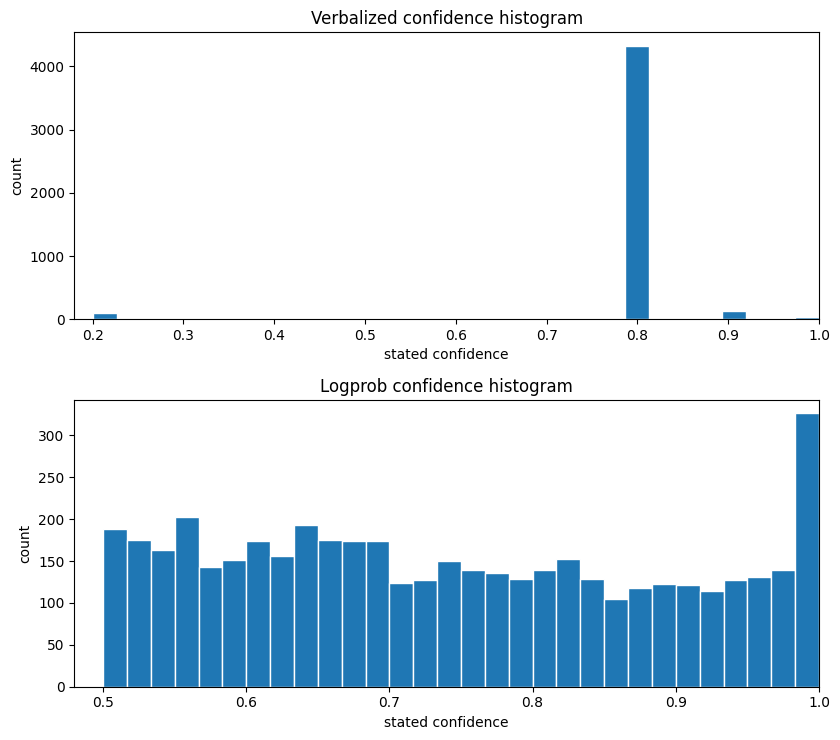

In [21]:
# histograms of both confidence distributions. each subplot uses its own
# equal-width edges and its own x-range so a narrow / constant signal stays
# visible next to a wide one.
def _plot_hist(ax, stats_, title, fallback_width=0.02):
    """draw one histogram, expanding bar widths if the data range collapsed.

    when the upstream ece function sees a constant signal (min == max) it
    emits a single bin of width 1e-12 to avoid divide-by-zero downstream.
    that bar is invisible at any reasonable axis scale, so we widen it to
    `fallback_width` purely for display — the count is unchanged.
    """
    edges = stats_["edges"]
    counts = stats_["count"]
    widths = np.diff(edges)
    # detect the degenerate single-bin case and inflate the bar width
    if len(widths) == 1 and widths[0] < 1e-3:
        center = edges[0]
        ax.bar([center - fallback_width / 2], counts, width=fallback_width,
               edgecolor="white")
        ax.annotate(
            f"all {int(counts[0])} examples at confidence = {center:.2f}\n"
            "(model emits a single value — no introspective range)",
            xy=(center, counts[0]), xytext=(0.5, 0.95), textcoords="axes fraction",
            ha="center", va="top",
            bbox=dict(boxstyle="round,pad=0.4", fc="lightyellow", ec="gray"),
        )
        # widen x range so the bar isn't pinned to the edge
        pad = max(0.05, fallback_width)
        ax.set_xlim(max(0.0, center - pad), min(1.0, center + pad))
    else:
        ax.bar(edges[:-1], counts, width=widths, align="edge", edgecolor="white")
        ax.set_xlim(max(0.0, edges[0] - 0.02), min(1.0, edges[-1] + 0.02))
    ax.set_ylabel("count")
    ax.set_xlabel("stated confidence")
    ax.set_title(title)


print(f"verbal:  {len(np.unique(conf_verbal))} unique values, "
      f"range [{conf_verbal.min():.3f}, {conf_verbal.max():.3f}]")
print(f"logprob: {len(np.unique(np.round(conf_logprob, 4)))} unique values (rounded), "
      f"range [{conf_logprob.min():.3f}, {conf_logprob.max():.3f}]")

fig, (ax_v, ax_l) = plt.subplots(2, 1, figsize=(8.5, 7.5))
_plot_hist(ax_v, stats_v, "Verbalized confidence histogram")
_plot_hist(ax_l, stats_l, "Logprob confidence histogram")
plt.tight_layout()
plt.show()

In [22]:
# raw value counts for the verbalized signal — what discrete confidences does
# the model actually emit? useful sanity check on whether the model uses the
# full 0-100 scale or sticks to a few values.
# (the logprob signal is continuous in [0.5, 1.0] so a value-counts view isn't
# useful for it — see the histogram below instead.)
conf_ints = np.round(conf_verbal * 100).astype(int)
uniq, cnt = np.unique(conf_ints, return_counts=True)
print(f"verbalized: {len(uniq)} unique stated confidence values")
for c, n in zip(uniq, cnt):
    print(f"  {c:3d}: {n:5d}")

# quick summary of the logprob signal — distribution shape only
print(f"\nlogprob: min={conf_logprob.min():.3f}  "
      f"median={np.median(conf_logprob):.3f}  "
      f"max={conf_logprob.max():.3f}  "
      f"(continuous in [0.5, 1.0] by construction)")

verbalized: 6 unique stated confidence values
   20:    95
   50:     2
   80:  4322
   90:   137
   95:     2
  100:    38

logprob: min=0.500  median=0.731  max=1.000  (continuous in [0.5, 1.0] by construction)


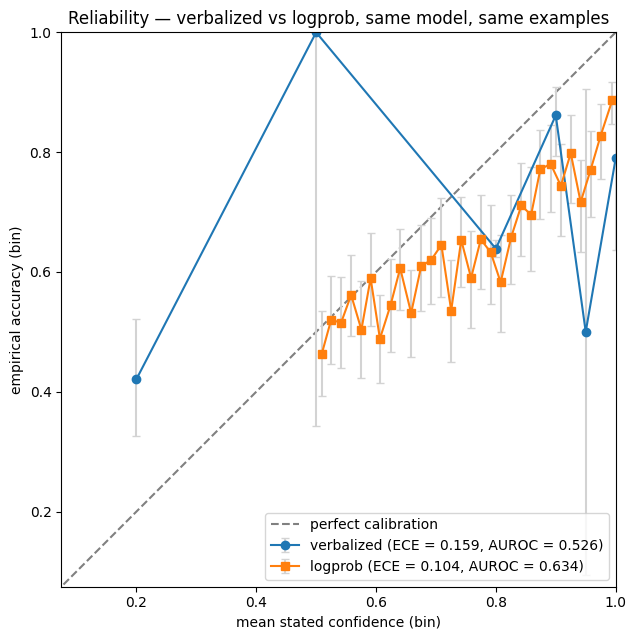

In [23]:
# reliability diagram with BOTH signals overlaid + 95% wilson intervals on each
# bin's empirical accuracy
def _bin_summary(stats_):
    """compute per-bin wilson intervals + valid mask for plotting."""
    acc = stats_["accuracy"]
    counts = stats_["count"]
    lowers = np.full_like(acc, np.nan)
    uppers = np.full_like(acc, np.nan)
    for i, (a, c) in enumerate(zip(acc, counts)):
        if c == 0 or np.isnan(a):
            continue
        lowers[i], uppers[i] = wilson_interval(a * c, c)
    valid = ~np.isnan(acc)
    return acc, lowers, uppers, valid


acc_v, lo_v, hi_v, valid_v = _bin_summary(stats_v)
acc_l, lo_l, hi_l, valid_l = _bin_summary(stats_l)
mean_v = stats_v["mean_confidence"]
mean_l = stats_l["mean_confidence"]

# zoom to a shared range covering both signals' data + cis, with small padding;
# keeping axes equal preserves the meaning of the 45° line
def _range(*arrays):
    vals = np.concatenate([np.asarray(a, dtype=float) for a in arrays])
    vals = vals[~np.isnan(vals)]
    return vals.min(), vals.max()

lo_x_v, hi_x_v = _range(mean_v[valid_v], lo_v[valid_v])
lo_x_l, hi_x_l = _range(mean_l[valid_l], lo_l[valid_l])
hi_y_v = np.nanmax(hi_v[valid_v])
hi_y_l = np.nanmax(hi_l[valid_l])

axis_lo = max(0.0, min(lo_x_v, lo_x_l) - 0.02)
axis_hi = min(1.0, max(hi_x_v, hi_x_l, hi_y_v, hi_y_l, 1.0) + 0.01)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot([0, 1], [0, 1], "--", color="gray", label="perfect calibration")

ax.errorbar(
    mean_v[valid_v], acc_v[valid_v],
    yerr=np.vstack([acc_v - lo_v, hi_v - acc_v])[:, valid_v],
    fmt="o-", capsize=3, ecolor="lightgray",
    color="C0", label=f"verbalized (ECE = {ece_v:.3f}, AUROC = {auroc_v:.3f})",
)
ax.errorbar(
    mean_l[valid_l], acc_l[valid_l],
    yerr=np.vstack([acc_l - lo_l, hi_l - acc_l])[:, valid_l],
    fmt="s-", capsize=3, ecolor="lightgray",
    color="C1", label=f"logprob (ECE = {ece_l:.3f}, AUROC = {auroc_l:.3f})",
)

ax.set_xlabel("mean stated confidence (bin)")
ax.set_ylabel("empirical accuracy (bin)")
ax.set_title("Reliability — verbalized vs logprob, same model, same examples")
ax.set_xlim(axis_lo, axis_hi)
ax.set_ylim(axis_lo, axis_hi)
ax.set_aspect("equal")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()